Universidade do Vale do Itajaí<br>
PPGCA - Programa de Pós-Graduação em Computação Aplicada<br>
Aprendizado Profundo<br>
Prof. Felipe Viel<br>
Conteúdo: Redes Neurais Recorrentes<br>

# Exercício 9: Redes Neurais Recorrentes

Neste exercício você irá utilizar Redes Neurais Recorrentes (RNNs) para trabalhar com dados sequenciais. A atividade foi organizada a partir dos conceitos apresentados na aula de Redes Neurais Recorrentes, incluindo: representação de sequências, RNN, propagação para frente, BPTT, desaparecimento/explosão de gradientes, LSTM, GRU, RNN bidirecional e *word embeddings*. 

O problema prático será a classificação de sentimentos no conjunto IMDB. A ideia é começar com uma solução simples e, progressivamente, investigar por que as arquiteturas recorrentes foram propostas e quando arquiteturas com portas, como LSTM e GRU, podem ser vantajosas.

### Objetivos

Ao final, você deverá ser capaz de:

- identificar diferentes tipos de problemas sequenciais;
- explicar a necessidade de memória/estado em uma RNN;
- interpretar as principais equações de uma RNN;
- preparar sequências com vocabulário, índices e *padding*;
- compreender a função da camada `Embedding`;
- implementar `SimpleRNN`, `LSTM`, `GRU` e, opcionalmente, uma RNN bidirecional;
- compreender conceitualmente o BPTT;
- investigar os problemas de *vanishing* e *exploding gradient*;
- comparar desempenho, quantidade de parâmetros e custo computacional;
- justificar a arquitetura final escolhida.

> **Importante:** não procure apenas a maior acurácia. O principal objetivo é relacionar **conceito -> implementação -> experimento -> interpretação**.


<div align="center">

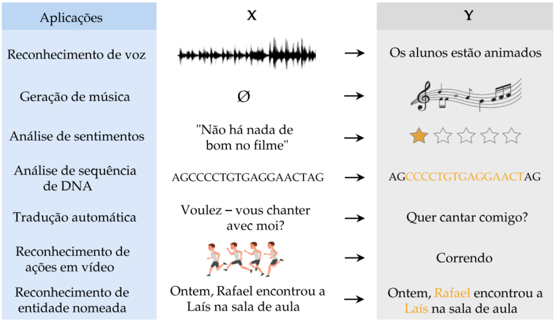

*Exemplos de dados sequenciais apresentados nos slides: voz, música, sentimentos, DNA, tradução e reconhecimento de entidades. — aula sobre Redes Neurais Recorrentes, slide 2.*

</div>

## 1. Dados sequenciais

Uma sequência pode ser representada por

$$X=(x^{\langle1\rangle},x^{\langle2\rangle},\ldots,x^{\langle T_x\rangle}).$$

O índice $t$ representa a posição temporal/seqüencial. Em NLP, por exemplo, $x^{\langle t\rangle}$ pode representar a palavra que aparece na posição $t$.

Nos slides, $T_x$ representa o comprimento da entrada e $T_y$ o comprimento da saída. Esses valores podem ser iguais ou diferentes. 

### Tarefa 1

Classifique os problemas abaixo como **many-to-one**, **one-to-many**, **many-to-many com comprimentos iguais** ou **many-to-many com comprimentos diferentes**:

1. Classificação de sentimento de uma frase.
2. Geração de música a partir de uma semente.
3. Reconhecimento de entidade nomeada, atribuindo um rótulo a cada palavra.
4. Tradução automática.
5. Previsão de uma variável a partir de uma janela temporal.

Explique cada resposta.

### Dica

Pergunte: **quantos elementos entram na rede e quantos elementos precisam sair?**


<div align="center">

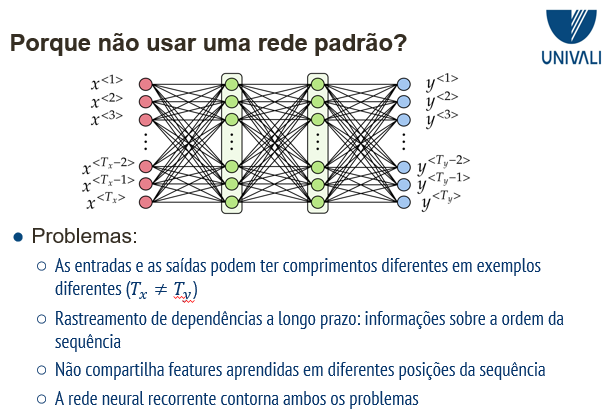

*A aula destaca por que uma rede padrão é inadequada para várias tarefas sequenciais: comprimentos diferentes, dependências de longo prazo e ausência de compartilhamento entre posições. — aula sobre Redes Neurais Recorrentes, slide 6.*

</div>

## 2. Por que não utilizar simplesmente uma rede Dense?

Uma rede convencional pode receber uma entrada vetorial fixa, mas problemas sequenciais apresentam três dificuldades importantes:

1. **Comprimento variável:** frases diferentes podem ter quantidades diferentes de palavras.
2. **Ordem:** a posição dos elementos pode alterar o significado.
3. **Dependências:** uma decisão em $t$ pode depender de informações que apareceram muito antes.

Além disso, queremos que o mesmo mecanismo seja reutilizado em diferentes posições da sequência. É justamente essa ideia de **compartilhamento de parâmetros ao longo do tempo** que aparece na RNN.

### Tarefa 2

Considere as frases:

- `O filme é bom`
- `O filme não é bom`

Explique por que um modelo que simplesmente agregasse as palavras sem considerar sua ordem poderia ter dificuldade nesse exemplo.


<div align="center">

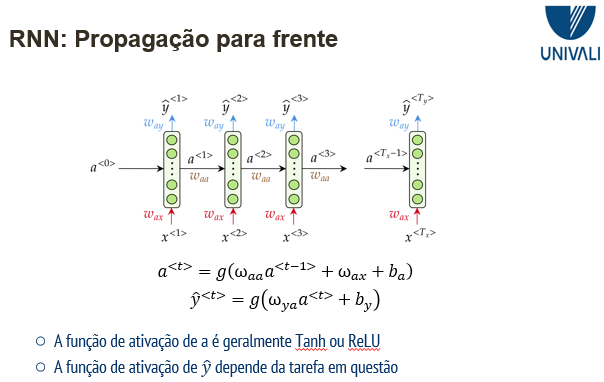

*Propagação para frente de uma RNN desenrolada no tempo, com o estado oculto passando de um instante para o seguinte. — aula sobre Redes Neurais Recorrentes, slide 9.*

</div>

## 3. RNN: estado oculto e propagação para frente

A ideia central de uma RNN é manter um estado oculto $a^{\langle t\rangle}$:

$$
a^{\langle t\rangle}=g\left(W_{aa}a^{\langle t-1\rangle}+W_{ax}x^{\langle t\rangle}+b_a\right).
$$

A saída pode ser calculada por:

$$
\hat y^{\langle t\rangle}=g_y\left(W_{ya}a^{\langle t\rangle}+b_y\right).
$$

A forma compacta apresentada na aula é:

$$
a^{\langle t\rangle}=g\left(W_a\begin{bmatrix}a^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_a\right).
$$

Normalmente, $a^{\langle0\rangle}$ é inicializado com zeros. Os pesos são compartilhados entre os diferentes instantes. 

### Tarefa 3 — interpretação da equação

Explique:

1. o papel de $a^{\langle t-1\rangle}$;
2. o papel de $x^{\langle t\rangle}$;
3. o que representa $W_{aa}$;
4. por que o estado pode ser interpretado como uma forma de memória;
5. por que os mesmos pesos são reutilizados em todos os passos.

### Dica

Pense na pergunta: **o que a rede precisa carregar do passado para interpretar a entrada atual?**


## 4. Representação das palavras: índice, one-hot e embedding

Os slides apresentam inicialmente uma lista de vocabulário, na qual cada palavra recebe um índice. 

Se o vocabulário possui $V$ palavras, uma representação *one-hot* possui dimensão $V$. Para a palavra $w$:

$$o_w\in\mathbb{R}^{V}.$$

Embora simples, essa representação não expressa similaridade semântica: para palavras diferentes, o produto interno entre os vetores *one-hot* é zero. 

Com *word embeddings*, cada palavra passa a ser representada por um vetor menor e denso:

$$e_w\in\mathbb{R}^{d}.$$

Se $E$ for a matriz de embeddings:

$$E\in\mathbb{R}^{d\times V},$$

então:

$$e_w=Eo_w.$$

Essa é a formulação apresentada no último slide da aula. 

Uma medida comum para comparar embeddings é a similaridade de cosseno:

$$\operatorname{sim}(w_1,w_2)=\frac{e_{w_1}^{T}e_{w_2}}{\|e_{w_1}\|\|e_{w_2}\|}.$$

### Tarefa 4

Explique por que `Embedding` é mais interessante que *one-hot* para alimentar uma RNN.


<div align="center">

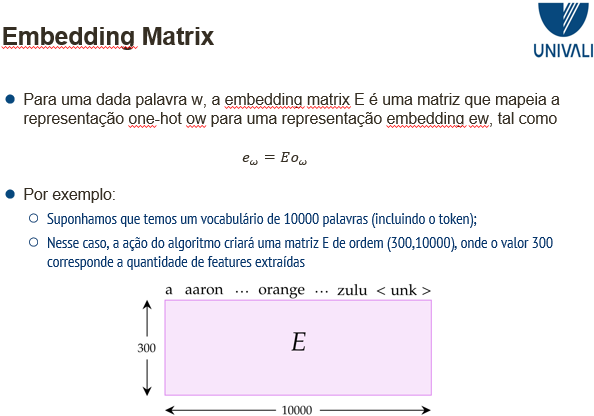

*A matriz de embeddings apresentada na aula realiza o mapeamento entre uma representação one-hot e um vetor denso de características. — aula sobre Redes Neurais Recorrentes, slide 46.*

</div>

## 5. Preparação do conjunto IMDB

Utilizaremos o conjunto IMDB disponível no Keras. Cada avaliação já é fornecida como uma sequência de índices de palavras.

### Como começar

Execute o código e investigue os formatos antes de construir a rede.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb

print("TensorFlow:", tf.__version__)

NUM_WORDS = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("Primeira sequência:", x_train[0][:20])
print("Classe:", y_train[0])


### Tarefa 5

Determine:

- número de amostras de treinamento e teste;
- valores possíveis de `y_train`;
- tamanho mínimo, máximo, média e mediana das avaliações;
- distribuição dos tamanhos.

### Dica

```python
lengths = np.array([len(x) for x in x_train])
```

Depois utilize `np.min`, `np.max`, `np.mean` e `np.median` e faça um histograma.


In [ ]:
lengths = np.array([len(x) for x in x_train])

print("Mínimo:", np.min(lengths))
print("Máximo:", np.max(lengths))
print("Média:", np.mean(lengths))
print("Mediana:", np.median(lengths))

plt.figure(figsize=(8,4))
plt.hist(lengths, bins=50)
plt.xlabel("Número de tokens")
plt.ylabel("Quantidade")
plt.grid()
plt.show()


## 6. Padding e truncamento

Como as sequências têm comprimentos diferentes, vamos utilizar um comprimento máximo $T$.

Após o *padding*, a entrada pode ser vista como:

$$X\in\mathbb{N}^{N\times T},$$

onde $N$ é o número de amostras e $T$ o número máximo de posições temporais.

Se uma sequência for menor que $T$, serão inseridos valores de preenchimento. Se for maior, será truncada.

### Tarefa 6

1. Use inicialmente `MAXLEN = 200`.
2. Repita a preparação para `50`, `100`, `200` e `400`.
3. Discuta o compromisso entre informação preservada e custo computacional.


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAXLEN = 200
x_train_pad = pad_sequences(x_train, maxlen=MAXLEN)
x_test_pad = pad_sequences(x_test, maxlen=MAXLEN)

print(x_train_pad.shape)
print(x_test_pad.shape)


# Parte II — Baseline e `SimpleRNN`

## 7. Baseline sem recorrência

Antes de usar uma RNN, precisamos de uma referência. Um baseline simples será:

$$
\text{índices}\rightarrow\text{Embedding}\rightarrow\text{média temporal}\rightarrow\text{Dense}.
$$

A média temporal elimina explicitamente a informação de ordem. Isso permitirá comparar posteriormente o ganho obtido ao introduzir recorrência.

### Como começar

Complete os `...` abaixo.


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

def make_baseline():
    model = Sequential([
        Embedding(input_dim=..., output_dim=32),
        GlobalAveragePooling1D(),
        Dense(1, activation=...)
    ])
    return model

baseline = make_baseline()
baseline.summary()


### Tarefa 7

Compile e treine o baseline com:

- `binary_crossentropy`;
- Adam;
- `batch_size=128`;
- 5 épocas;
- 20% para validação.

Calcule a acurácia no teste e faça os gráficos de treinamento.

Para classificação binária, a função de perda pode ser escrita como:

$$
L=-[y\log(\hat y)+(1-y)\log(1-\hat y)].
$$


In [ ]:
baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_baseline = baseline.fit(
    x_train_pad, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128
)

print("Teste:", baseline.evaluate(x_test_pad, y_test, verbose=0))


## 8. `SimpleRNN`

Agora substitua a agregação temporal por uma camada recorrente:

$$
\text{Embedding}\rightarrow\text{SimpleRNN}\rightarrow\text{Dense}.
$$

A `SimpleRNN` implementa a ideia de estado recorrente apresentada nos slides.

### Como começar



In [ ]:
from tensorflow.keras.layers import SimpleRNN

def make_rnn(units=64):
    model = Sequential([
        Embedding(input_dim=NUM_WORDS, output_dim=32),
        SimpleRNN(units),
        Dense(1, activation="sigmoid")
    ])
    return model

rnn = make_rnn()
rnn.summary()


### Tarefa 8

Treine a `SimpleRNN` nas mesmas condições do baseline e compare:

- acurácia de validação;
- acurácia de teste;
- número de parâmetros;
- tempo de treinamento;
- curvas de `loss` e `accuracy`.

### Perguntas

1. A recorrência melhorou o resultado?
2. Qual informação passou a ser utilizada que não era utilizada pelo baseline?
3. O custo computacional aumentou?
4. Há sinais de overfitting?


## 9. Retropropagação através do tempo — BPTT

No caso de uma RNN, a perda pode ser acumulada ao longo dos passos:

$$
L=\sum_{t=1}^{T_y}L^{\langle t\rangle}.
$$

Durante a retropropagação, o gradiente percorre também as conexões temporais. Esse processo é conhecido como **Backpropagation Through Time (BPTT)**. 

A repetição de produtos durante muitos passos ajuda a explicar dois problemas:

- **desaparecimento do gradiente:** fatores menores que 1 podem fazer o gradiente tender rapidamente a zero;
- **explosão do gradiente:** fatores maiores que 1 podem fazer o gradiente crescer muito.

Os slides apresentam *gradient clipping* como uma estratégia prática para a explosão do gradiente. 

### Tarefa 9

Explique por que:

$$0.5^{20}\approx9.54\times10^{-7}$$

enquanto

$$1.5^{20}\approx3325.$$

Relacione essa observação com os gradientes em uma RNN.


<div align="center">

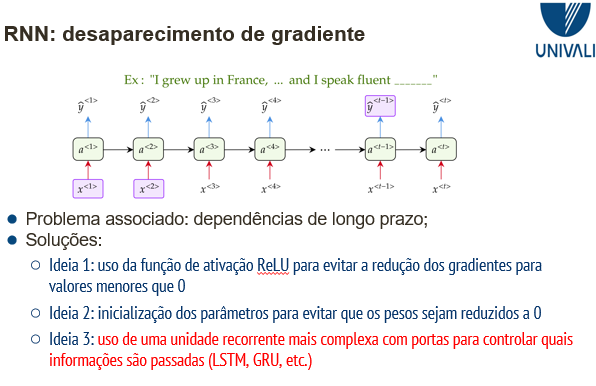

*O desaparecimento do gradiente é relacionado, na aula, às dependências de longo prazo; LSTM e GRU aparecem como soluções baseadas em unidades com portas. — aula sobre Redes Neurais Recorrentes, slide 20.*

</div>

### Tarefa 10 — Gradient clipping

Treine uma configuração da RNN com e sem:

```python
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3,
    clipnorm=1.0
)
```

Não é necessário provocar uma explosão extrema. O objetivo é entender a técnica e discutir quando ela pode ser útil.


# Parte III — LSTM

## 10. Long Short-Term Memory

A LSTM adiciona um estado de célula $c^{\langle t\rangle}$ e portas que controlam o fluxo de informação. Os slides descrevem quatro etapas: **Forget → Store → Update → Output**. 

A porta de esquecimento é:

$$
\Gamma_f^{\langle t\rangle}=\sigma\left(W_f\begin{bmatrix}a^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_f\right).
$$

Valores próximos de 0 indicam esquecimento; valores próximos de 1 indicam manutenção. 


<div align="center">

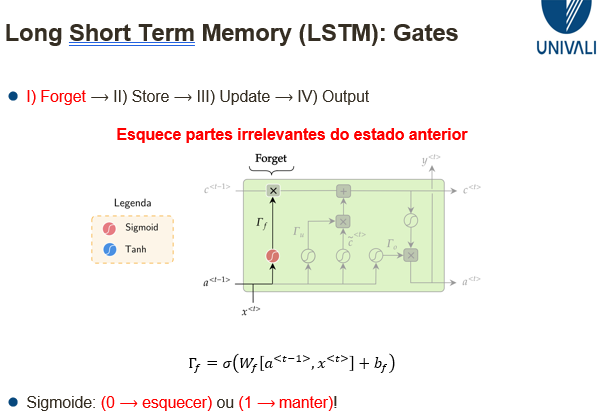

*Portas da LSTM: a porta de esquecimento controla quanto do estado anterior deve ser mantido. — aula sobre Redes Neurais Recorrentes, slide 23.*

</div>

A LSTM também calcula uma porta de atualização e um candidato:

$$
\Gamma_u^{\langle t\rangle}=\sigma\left(W_u\begin{bmatrix}a^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_u\right),
$$

$$
\tilde c^{\langle t\rangle}=\tanh\left(W_c\begin{bmatrix}a^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_c\right).
$$

O estado é atualizado por:

$$
c^{\langle t\rangle}=\Gamma_u^{\langle t\rangle}\odot\tilde c^{\langle t\rangle}+\Gamma_f^{\langle t\rangle}\odot c^{\langle t-1\rangle}.
$$

E a saída:

$$a^{\langle t\rangle}=\Gamma_o^{\langle t\rangle}\odot\tanh(c^{\langle t\rangle}).$$

A ideia não é memorizar tudo, mas aprender **o que preservar, atualizar e expor**. 

### Tarefa 11

Associe cada porta à pergunta que ela ajuda a responder:

- Forget
- Update/Store
- Output

Perguntas:

A. O que devo enviar como estado oculto?
B. O que devo manter do passado?
C. Que informação nova devo incorporar?


In [ ]:
from tensorflow.keras.layers import LSTM

def make_lstm(units=64):
    model = Sequential([
        Embedding(input_dim=NUM_WORDS, output_dim=32),
        LSTM(units),
        Dense(1, activation="sigmoid")
    ])
    return model

lstm = make_lstm()
lstm.summary()


### Tarefa 12 — SimpleRNN × LSTM

Treine a LSTM mantendo constantes, tanto quanto possível, `MAXLEN`, dimensão do embedding, número de unidades, batch size, taxa de aprendizado e número de épocas.

Compare:

- parâmetros;
- tempo;
- melhor validação;
- teste;
- curvas.

**Conclusão:** o aumento de complexidade compensou? Justifique usando os seus resultados.


# Parte IV — GRU

## 11. Gated Recurrent Unit

A GRU também utiliza portas, mas possui uma estrutura mais compacta. Nos slides aparecem as portas **reset** e **update**. 

A porta de reset é:

$$
\Gamma_r^{\langle t\rangle}=\sigma\left(W_r\begin{bmatrix}a^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_r\right).
$$

A porta de atualização é:

$$
\Gamma_u^{\langle t\rangle}=\sigma\left(W_u\begin{bmatrix}a^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_u\right).
$$

Uma forma equivalente à apresentada na aula é:

$$
\tilde c^{\langle t\rangle}=\tanh\left(W_c\begin{bmatrix}\Gamma_r^{\langle t\rangle}\odot c^{\langle t-1\rangle}\\x^{\langle t\rangle}\end{bmatrix}+b_c\right),
$$

$$
c^{\langle t\rangle}=\Gamma_u^{\langle t\rangle}\odot\tilde c^{\langle t\rangle}+(1-\Gamma_u^{\langle t\rangle})\odot c^{\langle t-1\rangle}.
$$


<div align="center">

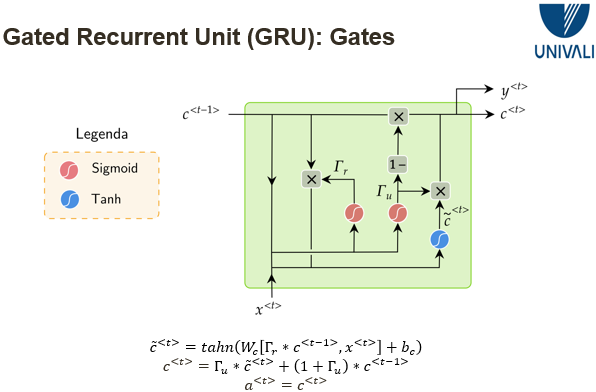

*A GRU utiliza portas de reset e atualização para controlar a contribuição do estado anterior e do novo candidato. — aula sobre Redes Neurais Recorrentes, slide 30.*

</div>

In [ ]:
from tensorflow.keras.layers import GRU

def make_gru(units=64):
    model = Sequential([
        Embedding(input_dim=NUM_WORDS, output_dim=32),
        GRU(units),
        Dense(1, activation="sigmoid")
    ])
    return model

gru = make_gru()
gru.summary()


### Tarefa 13 — SimpleRNN × LSTM × GRU

Treine as três arquiteturas sob condições comparáveis.

Monte uma tabela e discuta:

1. Qual teve melhor desempenho?
2. Quem tem mais parâmetros
3. Qual teve menor complexidade?
4. Qual foi mais rápido?
5. Houve uma diferença suficientemente grande para justificar uma arquitetura mais complexa?


# Parte V — Bidirectional e Deep RNN

## 12. RNN bidirecional

Uma RNN convencional usa principalmente o contexto anterior. Uma **Bidirectional RNN** processa a sequência nas duas direções e combina as informações.

Isso é útil quando o elemento atual pode ser melhor interpretado usando também palavras posteriores. Porém, a principal limitação apresentada nos slides é que a sequência completa precisa estar disponível antes do processamento. fileciteturn3file0L408-L423


<div align="center">

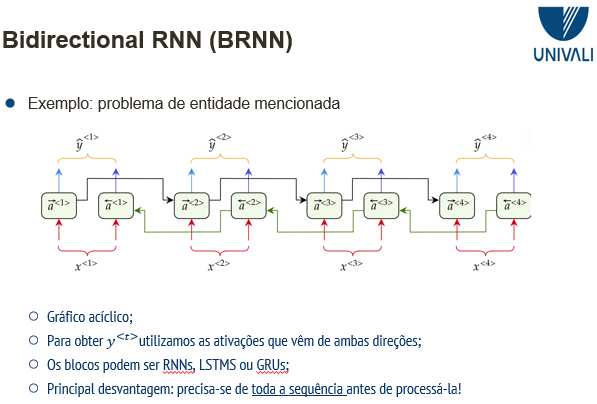

*A BRNN utiliza ativações das duas direções; a aula destaca como desvantagem a necessidade de conhecer a sequência completa. — aula sobre Redes Neurais Recorrentes, slide 33.*

</div>

In [ ]:
from tensorflow.keras.layers import Bidirectional

def make_bilstm(units=64):
    model = Sequential([
        Embedding(input_dim=NUM_WORDS, output_dim=32),
        Bidirectional(LSTM(units)),
        Dense(1, activation="sigmoid")
    ])
    return model

bilstm = make_bilstm()
bilstm.summary()


### Tarefa 14 — Bidirecionalidade

Treine a BiLSTM e compare com a LSTM unidirecional.

Responda:

1. Quantos parâmetros adicionais surgiram?
2. O desempenho melhorou?
3. A utilização de contexto futuro é válida em classificação de uma frase inteira?
4. Seria válida em uma aplicação de previsão em tempo real? Justifique.


## 13. Deep RNN

É possível empilhar camadas recorrentes. Para isso, uma camada intermediária precisa retornar **toda a sequência**:

```python
SimpleRNN(64, return_sequences=True)
```

A camada seguinte recebe então uma sequência, e não apenas o estado final.

Os slides também apresentam o conceito de **Deep RNN**, com várias camadas recorrentes empilhadas. fileciteturn3file0L426-L432


In [ ]:
def make_deep_rnn(units=64):
    model = Sequential([
        Embedding(input_dim=NUM_WORDS, output_dim=32),
        SimpleRNN(units, return_sequences=True),
        SimpleRNN(units),
        Dense(1, activation="sigmoid")
    ])
    return model

deep_rnn = make_deep_rnn()
deep_rnn.summary()


### Tarefa 15

Compare uma `SimpleRNN` com a versão profunda.

Explique por que `return_sequences=True` é necessário na primeira camada recorrente.


# Parte VI — Experimento sistemático

## 14. Efeito do tamanho da sequência

Escolha LSTM ou GRU e compare:

```text
MAXLEN = 50, 100, 200, 400
```

Para cada configuração, registre:

- número de parâmetros;
- tempo de treinamento;
- melhor acurácia de validação;
- acurácia no teste.

### Tarefa 16

Produza:

1. tabela de resultados;
2. gráfico de acurácia × `MAXLEN`;
3. gráfico de tempo × `MAXLEN`;
4. conclusão sobre o melhor compromisso entre informação e custo.

> Não reutilize os pesos de um modelo quando mudar `MAXLEN`: crie e treine um novo modelo.


## 15. Efeito da dimensão do embedding

Repita um experimento com:

```text
embedding_dim = 16, 32, 64, 128
```

A matriz de embeddings possui aproximadamente:

$$V\times d$$

parâmetros.

### Tarefa 17

Investigue como o aumento de $d$ altera:

- número de parâmetros;
- tempo;
- acurácia;
- overfitting.

Explique por que o número de parâmetros cresce com a dimensão do embedding.


## 16. Modelo final

Escolha a configuração que você considera mais adequada e faça um treinamento final.

Você pode alterar:

- `MAXLEN`;
- embedding dimension;
- número de unidades;
- SimpleRNN/LSTM/GRU;
- número de camadas;
- dropout;
- learning rate;
- batch size.

### Recomendação

Use `EarlyStopping` para evitar treinamento desnecessário:

```python
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)
```

Registre a **hipótese** antes de cada alteração importante. Por exemplo:

> "Aumentar o embedding de 32 para 64 pode melhorar a representação sem aumentar excessivamente o custo."


# Parte VII — Avaliação

## 17. Matriz de confusão e análise de erros

Para o modelo final, apresente:

- `model.summary()`;
- número de parâmetros;
- melhor acurácia de validação;
- acurácia no teste;
- curvas de treinamento;
- matriz de confusão;
- pelo menos 5 exemplos classificados incorretamente.

Para classificação binária:

$$
CM=\begin{bmatrix}TN&FP\\FN&TP\end{bmatrix}.
$$


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Substitua 'model' pelo seu modelo final.
y_prob = model.predict(x_test_pad, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativo", "Positivo"]
).plot()
plt.grid(False)
plt.show()


### Tarefa 18 — Análise de erros

Para pelo menos cinco erros, apresente:

- classe verdadeira;
- classe prevista;
- probabilidade prevista;
- trecho da avaliação.

Procure padrões como:

- negação (`not`, `never`);
- avaliações muito longas;
- ironia;
- vocabulário desconhecido;
- dependências de longo prazo;
- palavras ambíguas.

Depois responda: **os erros parecem estar associados à arquitetura, à representação dos dados ou à própria dificuldade da tarefa?**


# 18. Questões finais

1. Por que a ordem dos elementos é importante em dados sequenciais?
2. Qual é a função do estado oculto $a^{\langle t\rangle}$?
3. Por que os pesos são compartilhados entre os passos temporais?
4. O que é BPTT?
5. Por que ocorre vanishing gradient?
6. Para que serve gradient clipping?
7. Por que LSTM possui portas?
8. Qual é a função das portas reset e update da GRU?
9. Qual é a principal vantagem e a principal limitação de uma BRNN?
10. Por que `return_sequences=True` é necessário para empilhar RNNs?
11. Por que embeddings são preferíveis a one-hot em muitas aplicações de NLP?
12. Se duas arquiteturas possuem acurácia semelhante, como você escolheria entre elas para uma aplicação embarcada?
13. Compare RNN, CNN e Transformer quanto à forma de explorar dependências na sequência.


# 19. Desafio opcional — modelo de linguagem

Nos slides, o modelo de linguagem é apresentado como um modelo que estima probabilidades de sequências. Para uma sequência de palavras, pela regra da cadeia:

$$
P(y^{\langle1\rangle},\ldots,y^{\langle T\rangle})
=\prod_{t=1}^{T}P(y^{\langle t\rangle}|y^{\langle1\rangle},\ldots,y^{\langle t-1\rangle}).
$$

A rede pode ser treinada para prever a próxima palavra. 

### Desafio

Construa um pequeno modelo de linguagem em nível de palavra ou caractere:

1. construa o vocabulário;
2. crie pares `(entrada, próxima palavra)`;
3. treine uma RNN, GRU ou LSTM;
4. obtenha a distribuição da próxima palavra;
5. gere uma sequência iterativamente.

O fluxo conceitual é:

```text
entrada → RNN → probabilidades → próxima palavra
                     ↑              |
                     └──────────────┘
```

Para a geração, você pode terminar após um número fixo de passos ou ao encontrar `<EOS>`, conceito também apresentado na aula. 


# Entrega (não é um avaliação)

O notebook deverá apresentar, no mínimo:

- análise do IMDB;
- distribuição dos comprimentos;
- padding/truncamento;
- baseline;
- SimpleRNN;
- LSTM;
- GRU;
- comparação entre arquiteturas;
- experimento com `MAXLEN`;
- experimento com dimensão do embedding;
- modelo final;
- avaliação no teste;
- matriz de confusão;
- análise de erros;
- respostas às questões conceituais.

